Analiza priorytetow kategorii danych dla testów z 50 obiektami

In [48]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.stats import shapiro, kruskal, spearmanr, pearsonr, f_oneway
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import warnings
warnings.filterwarnings('ignore')

In [49]:
data = [
{'output': {'createdate': 90, 'name': 80, 'place': 70, 'type': 60, 'material': 50, 'technique': 40, 'size': 30, 'creator': 20, 'copyright': 10, 'inventorynumber': 0}, 'model': 'deepseek-ai/DeepSeek-V3-0324', 'query': 'Znajdź dzieła wykonane w trakcie wojny w danym państwie', 'elapsed_time': 4.428},
{'output': {'name': 100, 'createdate': 95, 'place': 90, 'inventorynumber': 30, 'type': 25, 'material': 20, 'technique': 15, 'size': 10, 'copyright': 5, 'creator': 0}, 'model': 'moonshotai/Kimi-K2-Instruct-0905', 'query': 'Znajdź dzieła wykonane w trakcie wojny w danym państwie', 'elapsed_time': 0.632},
{'output': {'createdate': 90, 'place': 80, 'type': 70}, 'model': 'openai/gpt-oss-20b:groq', 'query': 'Znajdź dzieła wykonane w trakcie wojny w danym państwie', 'elapsed_time': 1.196},
{'output': {'createdate': 100, 'name': 100, 'place': 100, 'technique': 100}, 'model': 'CohereLabs/command-a-translate-08-2025:cohere', 'query': 'Znajdź dzieła wykonane w trakcie wojny w danym państwie', 'elapsed_time': 2.044},
{'output': {'place': 100, 'createdate': 95, 'name': 90, 'technique': 70, 'type': 60, 'material': 50, 'size': 40, 'creator': 30, 'copyright': 10, 'inventorynumber': 5}, 'model': 'inclusionAI/Ling-1T:featherless-ai', 'query': 'Znajdź dzieła wykonane w trakcie wojny w danym państwie', 'elapsed_time': 8.394},
{'output': {'createdate': 90, 'name': 80, 'place': 70, 'creator': 60, 'type': 50, 'material': 40, 'technique': 30, 'size': 20, 'copyright': 10}, 'model': 'deepseek-ai/DeepSeek-V3-0324', 'query': 'Znajdź dzieła wykonane w trakcie wojny w danym państwie', 'elapsed_time': 3.447},
{'output': {'name': 100, 'createdate': 95, 'place': 90, 'inventorynumber': 85, 'type': 80, 'material': 75, 'technique': 70, 'size': 65, 'copyright': 60, 'creator': 55}, 'model': 'moonshotai/Kimi-K2-Instruct-0905', 'query': 'Znajdź dzieła wykonane w trakcie wojny w danym państwie', 'elapsed_time': 0.997},
{'output': {'inventorynumber': 20, 'createdate': 90, 'name': 80, 'size': 20, 'material': 20, 'technique': 20, 'place': 100, 'type': 20, 'copyright': 20, 'creator': 20}, 'model': 'openai/gpt-oss-20b:groq', 'query': 'Znajdź dzieła wykonane w trakcie wojny w danym państwie', 'elapsed_time': 1.461},
{'output': {'createdate': 100, 'name': 100, 'place': 100, 'inventorynumber': 50, 'material': 50, 'technique': 50, 'type': 50, 'copyright': 50, 'creator': 50, 'size': 0}, 'model': 'CohereLabs/command-a-translate-08-2025:cohere', 'query': 'Znajdź dzieła wykonane w trakcie wojny w danym państwie', 'elapsed_time': 2.98},
{'output': {'place': 100, 'createdate': 100, 'name': 100, 'type': 90, 'technique': 80, 'material': 70, 'creator': 60, 'size': 50, 'copyright': 10, 'inventorynumber': 5}, 'model': 'inclusionAI/Ling-1T:featherless-ai', 'query': 'Znajdź dzieła wykonane w trakcie wojny w danym państwie', 'elapsed_time': 7.805},
{'output': {'createdate': 90, 'name': 80, 'place': 70, 'type': 60, 'material': 50, 'technique': 40, 'size': 30, 'creator': 20, 'copyright': 10, 'inventorynumber': 0}, 'model': 'deepseek-ai/DeepSeek-V3-0324', 'query': 'Znajdź dzieła wykonane w trakcie wojny w danym państwie', 'elapsed_time': 3.265},
{'output': {'name': 100, 'createdate': 95, 'place': 90, 'inventorynumber': 85, 'type': 80, 'technique': 75, 'material': 70, 'size': 65, 'copyright': 60, 'creator': 55}, 'model': 'moonshotai/Kimi-K2-Instruct-0905', 'query': 'Znajdź dzieła wykonane w trakcie wojny w danym państwie', 'elapsed_time': 0.716},
{'output': {'inventorynumber': 20, 'createdate': 90, 'name': 75, 'size': 25, 'material': 30, 'technique': 40, 'place': 85, 'type': 80, 'copyright': 10, 'creator': 20}, 'model': 'openai/gpt-oss-20b:groq', 'query': 'Znajdź dzieła wykonane w trakcie wojny w danym państwie', 'elapsed_time': 1.128},
{'output': {'createdate': 100, 'name': 100, 'place': 100, 'inventorynumber': 50, 'material': 50, 'technique': 50, 'type': 50, 'copyright': 50, 'creator': 50, 'size': 0}, 'model': 'CohereLabs/command-a-translate-08-2025:cohere', 'query': 'Znajdź dzieła wykonane w trakcie wojny w danym państwie', 'elapsed_time': 2.247},
{'output': {'place': 100, 'createdate': 100, 'name': 100, 'type': 90, 'technique': 70, 'material': 60, 'size': 50, 'creator': 40, 'copyright': 30, 'inventorynumber': 20}, 'model': 'inclusionAI/Ling-1T:featherless-ai', 'query': 'Znajdź dzieła wykonane w trakcie wojny w danym państwie', 'elapsed_time': 8.295}
         ]

In [50]:
def prepare_dataframe(data):
    rows = []
    for entry in data:
        model = entry['model']
        output = entry['output']
        default_values = {
            'inventorynumber': 0, 'createdate': 0, 'name': 0, 'size': 0,
            'material': 0, 'technique': 0, 'place': 0, 'type': 0,
            'copyright': 0, 'creator': 0
        }
        row = default_values.copy()
        row.update(output)
        row['model'] = model
        rows.append(row)
    df = pd.DataFrame(rows)
    return df
df = prepare_dataframe(data)
print("PRZYGOTOWANIE DANYCH")
print(f"Rozmiar DataFrame: {df.shape}")
print(f"Modele: {df['model'].unique()}")
print(f"Liczba prób: {len(df)}")

PRZYGOTOWANIE DANYCH
Rozmiar DataFrame: (15, 11)
Modele: ['deepseek-ai/DeepSeek-V3-0324' 'moonshotai/Kimi-K2-Instruct-0905'
 'openai/gpt-oss-20b:groq' 'CohereLabs/command-a-translate-08-2025:cohere'
 'inclusionAI/Ling-1T:featherless-ai']
Liczba prób: 15


In [51]:
def descriptive_statistics(df):
    features = ['inventorynumber', 'createdate', 'name', 'size', 'material', 'technique', 'place', 'type', 'copyright', 'creator']
    stats_df = pd.DataFrame(index=features)
    for feature in features:
        values = df[feature]
        stats_df.loc[feature, 'Średnia'] = np.mean(values)
        stats_df.loc[feature, 'Mediana'] = np.median(values)
        stats_df.loc[feature, 'Odchylenie std'] = np.std(values)
        stats_df.loc[feature, 'Wariancja'] = np.var(values)
        stats_df.loc[feature, 'Min'] = np.min(values)
        stats_df.loc[feature, 'Max'] = np.max(values)
        stats_df.loc[feature, 'Zakres (max-min)'] = np.max(values) - np.min(values)
        stats_df.loc[feature, 'IQR'] = np.percentile(values, 75) - np.percentile(values, 25)
    return stats_df
print("STATYSTYKI OPISOWE")
stats_df = descriptive_statistics(df)
stats_df.round(2)

STATYSTYKI OPISOWE


,Średnia,Mediana,Odchylenie std,Wariancja,Min,Max,Zakres (max-min),IQR
inventorynumber,24.67,20.0,28.84,831.56,0.0,85.0,85.0,40.0
createdate,94.67,95.0,4.27,18.22,90.0,100.0,10.0,10.0
name,85.67,100.0,24.82,616.22,0.0,100.0,100.0,20.0
size,27.00,25.0,22.27,496.00,0.0,65.0,65.0,40.0
material,42.33,50.0,23.01,529.56,0.0,75.0,75.0,30.0
technique,50.00,50.0,26.52,703.33,0.0,100.0,100.0,35.0
place,89.67,90.0,11.61,134.89,70.0,100.0,30.0,17.5
type,57.67,60.0,25.49,649.56,0.0,90.0,90.0,30.0
copyright,22.33,10.0,21.04,442.89,0.0,60.0,60.0,30.0
creator,32.00,30.0,21.59,466.00,0.0,60.0,60.0,32.5


In [52]:
def shapiro_wilk_test(df):
    features = ['inventorynumber', 'createdate', 'name', 'size', 'material', 'technique', 'place', 'type', 'copyright', 'creator']
    results = []
    for feature in features:
        values = df[feature]
        values_clean = values[values != 0]
        if len(values_clean) > 3:
            stat, p = shapiro(values_clean)
            normalny = "Zachowana" if p > 0.05 else "Odrzucona"
        else:
            stat, p, normalny = np.nan, np.nan, "Brak danych"
        results.append({
            'Cecha': feature,
            'W-statystyka': round(stat, 3) if not np.isnan(stat) else 'N/A',
            'p-value': round(p, 3) if not np.isnan(p) else 'N/A',
            'Normalność': normalny
        })
    return pd.DataFrame(results)
shapiro_results = shapiro_wilk_test(df)
print("TEST SHAPIRO-WILKA (NORMALNOŚĆ)")
shapiro_results

TEST SHAPIRO-WILKA (NORMALNOŚĆ)


,Cecha,W-statystyka,p-value,Normalność
0,inventorynumber,0.865,0.088,Zachowana
1,createdate,0.782,0.002,Odrzucona
2,name,0.719,0.001,Odrzucona
3,size,0.931,0.419,Zachowana
4,material,0.919,0.243,Zachowana
5,technique,0.960,0.720,Zachowana
6,place,0.789,0.003,Odrzucona
7,type,0.924,0.250,Zachowana
8,copyright,0.777,0.004,Odrzucona
9,creator,0.830,0.021,Odrzucona


In [53]:
def covariance_analysis(df):
    features = ['inventorynumber', 'createdate', 'name', 'size', 'material', 'technique', 'place', 'type', 'copyright', 'creator']
    cov_matrix = df[features].cov()
    corr_matrix = df[features].corr()
    spearman_matrix = df[features].corr(method='spearman')
    return cov_matrix, corr_matrix, spearman_matrix
cov_matrix, corr_matrix, spearman_matrix = covariance_analysis(df)

In [54]:
cov_matrix.round(2)

,inventorynumber,createdate,name,size,material,technique,place,type,copyright,creator
inventorynumber,890.95,39.17,310.95,265.00,361.55,187.50,108.81,183.10,599.05,325.71
createdate,39.17,19.52,68.10,0.71,29.40,82.14,40.95,-0.83,36.55,32.86
name,310.95,68.10,660.24,198.57,332.26,460.71,139.52,-71.55,246.55,262.86
size,265.00,0.71,198.57,531.43,423.57,287.50,0.71,406.79,189.64,263.57
material,361.55,29.40,332.26,423.57,567.38,296.43,18.69,427.26,337.02,439.64
technique,187.50,82.14,460.71,287.50,296.43,753.57,160.71,94.64,180.36,233.93
place,108.81,40.95,139.52,0.71,18.69,160.71,144.52,-43.69,82.98,40.00
type,183.10,-0.83,-71.55,406.79,427.26,94.64,-43.69,695.95,179.05,308.57
copyright,599.05,36.55,246.55,189.64,337.02,180.36,82.98,179.05,474.52,327.14
creator,325.71,32.86,262.86,263.57,439.64,233.93,40.00,308.57,327.14,499.29


In [55]:
corr_matrix.round(2)

,inventorynumber,createdate,name,size,material,technique,place,type,copyright,creator
inventorynumber,1.00,0.30,0.41,0.39,0.51,0.23,0.30,0.23,0.92,0.49
createdate,0.30,1.00,0.60,0.01,0.28,0.68,0.77,-0.01,0.38,0.33
name,0.41,0.60,1.00,0.34,0.54,0.65,0.45,-0.11,0.44,0.46
size,0.39,0.01,0.34,1.00,0.77,0.45,0.00,0.67,0.38,0.51
material,0.51,0.28,0.54,0.77,1.00,0.45,0.07,0.68,0.65,0.83
technique,0.23,0.68,0.65,0.45,0.45,1.00,0.49,0.13,0.30,0.38
place,0.30,0.77,0.45,0.00,0.07,0.49,1.00,-0.14,0.32,0.15
type,0.23,-0.01,-0.11,0.67,0.68,0.13,-0.14,1.00,0.31,0.52
copyright,0.92,0.38,0.44,0.38,0.65,0.30,0.32,0.31,1.00,0.67
creator,0.49,0.33,0.46,0.51,0.83,0.38,0.15,0.52,0.67,1.00


In [56]:
def find_strong_correlations(corr_matrix, threshold=0.5):
    """Znajdź silne korelacje między cechami"""
    strong_corrs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr = abs(corr_matrix.iloc[i, j])
            if corr > threshold:
                feature1 = corr_matrix.columns[i]
                feature2 = corr_matrix.columns[j]
                strong_corrs.append({
                    'Para': f"{feature1} i {feature2}",
                    'Korelacja': round(corr, 2),
                    'Kierunek': 'Dodatnia' if corr_matrix.iloc[i, j] > 0 else 'Ujemna'
                })
    return pd.DataFrame(strong_corrs).sort_values('Korelacja', ascending=False)
strong_corrs = find_strong_correlations(corr_matrix)
print("SILNE KORELACJE")
strong_corrs

SILNE KORELACJE


,Para,Korelacja,Kierunek
1,inventorynumber i copyright,0.92,Dodatnia
12,material i creator,0.83,Dodatnia
4,createdate i place,0.77,Dodatnia
7,size i material,0.77,Dodatnia
10,material i type,0.68,Dodatnia
3,createdate i technique,0.68,Dodatnia
8,size i type,0.67,Dodatnia
14,copyright i creator,0.67,Dodatnia
11,material i copyright,0.65,Dodatnia
6,name i technique,0.65,Dodatnia


In [57]:
def kruskal_wallis_test(df):
    features = ['inventorynumber', 'createdate', 'name', 'size', 'material', 'technique', 'place', 'type', 'copyright', 'creator']
    models = df['model'].unique()
    results = []
    for feature in features:
        groups = [df[df['model'] == model][feature].values for model in models]
        groups = [g for g in groups if len(g) > 0]
        if len(groups) >= 2:
            stat, p = kruskal(*groups)
            istotne = "Tak" if p < 0.05 else "Nie"
        else:
            stat, p, istotne = np.nan, np.nan, "N/A"
        results.append({
            'Cecha': feature,
            'H-statystyka': round(stat, 2) if not np.isnan(stat) else 'N/A',
            'p-value': round(p, 3) if not np.isnan(p) else 'N/A',
            'Istotne różnice': istotne
        })
    return pd.DataFrame(results)
kruskal_results = kruskal_wallis_test(df)
print("TEST KRUSKALA-WALLISA (RÓŻNICE MIĘDZY MODELAMI)")
kruskal_results

TEST KRUSKALA-WALLISA (RÓŻNICE MIĘDZY MODELAMI)


,Cecha,H-statystyka,p-value,Istotne różnice
0,inventorynumber,8.93,0.063,Nie
1,createdate,13.24,0.010,Tak
2,name,12.80,0.012,Tak
3,size,9.70,0.046,Tak
4,material,6.79,0.148,Nie
5,technique,8.00,0.092,Nie
6,place,11.85,0.018,Tak
7,type,6.07,0.194,Nie
8,copyright,2.26,0.688,Nie
9,creator,3.26,0.516,Nie


In [58]:
def coefficient_of_variation(df):
    models = df['model'].unique()
    features = ['inventorynumber', 'createdate', 'name', 'size', 'material', 'technique', 'place', 'type', 'copyright', 'creator']
    cv_results = []
    for model in models:
        model_data = df[df['model'] == model]
        if len(model_data) > 1:
            cvs = []
            for feature in features:
                values = model_data[feature].values
                if np.mean(values) != 0:
                    cv = (np.std(values) / np.mean(values)) * 100
                    cvs.append(cv)

            avg_cv = np.mean(cvs) if cvs else 0
        else:
            avg_cv = 0
        if avg_cv < 10:
            interpretacja = "Bardzo wysoka spójność"
        elif avg_cv < 15:
            interpretacja = "Wysoka spójność"
        elif avg_cv < 25:
            interpretacja = "Średnia spójność"
        else:
            interpretacja = "Niska spójność"
        cv_results.append({
            'Model': model,
            'CV (%)': round(avg_cv, 1),
            'Interpretacja': interpretacja
        })
    return pd.DataFrame(cv_results).sort_values('CV (%)')
cv_results = coefficient_of_variation(df)
print("WSPÓŁCZYNNIK ZMIENNOŚCI (CV) DLA MODELI")
cv_results

WSPÓŁCZYNNIK ZMIENNOŚCI (CV) DLA MODELI


,Model,CV (%),Interpretacja
0,deepseek-ai/DeepSeek-V3-0324,11.7,Wysoka spójność
4,inclusionAI/Ling-1T:featherless-ai,21.1,Średnia spójność
1,moonshotai/Kimi-K2-Instruct-0905,36.6,Niska spójność
3,CohereLabs/command-a-translate-08-2025:cohere,43.2,Niska spójność
2,openai/gpt-oss-20b:groq,57.8,Niska spójność


In [59]:
def detect_outliers(df):
    features = ['inventorynumber', 'createdate', 'name', 'size', 'material', 'technique', 'place', 'type', 'copyright', 'creator']
    outliers = []
    for feature in features:
        values = df[feature].values
        Q1 = np.percentile(values, 25)
        Q3 = np.percentile(values, 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        feature_outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
        for _, row in feature_outliers.iterrows():
            outliers.append({
                'Cecha': feature,
                'Model': row['model'],
                'Wartość': row[feature],
                'Typ': 'Niski' if row[feature] < lower_bound else 'Wysoki'
            })
    return pd.DataFrame(outliers)
outliers_df = detect_outliers(df)
print("WYKRYTE WARTOŚCI ODSTAJĄCE")
if len(outliers_df) > 0:
    print(outliers_df)
else:
    print("Brak wartości odstających")

WYKRYTE WARTOŚCI ODSTAJĄCE
  Cecha                                          Model  Wartość    Typ
0  name                        openai/gpt-oss-20b:groq        0  Niski
1  type  CohereLabs/command-a-translate-08-2025:cohere        0  Niski


In [60]:
def linear_regression_analysis(df):
    from sklearn.linear_model import LinearRegression
    from sklearn.preprocessing import LabelEncoder
    features = ['inventorynumber', 'createdate', 'name', 'size', 'material', 'technique', 'place', 'type', 'copyright', 'creator']
    df_encoded = pd.get_dummies(df, columns=['model'], prefix='model')
    predictors = features + [col for col in df_encoded.columns if col.startswith('model_')]
    results = {}
    for target_feature in features:
        if target_feature in predictors:
            X = df_encoded[predictors].drop(columns=[target_feature])
        else:
            X = df_encoded[predictors]

        y = df_encoded[target_feature]
        model = LinearRegression()
        model.fit(X, y)
        r2 = model.score(X, y)
        coefficients = dict(zip(X.columns, model.coef_))
        intercept = model.intercept_

        results[target_feature] = {
            'R2': r2,
            'Intercept': intercept,
            'Coefficients': coefficients
        }
    return results
regression_results = linear_regression_analysis(df)
print("ANALIZA REGRESJI LINIOWEJ")
print("najlepsze wyniki:")
for feature, result in list(regression_results.items())[:3]:
    print(f"\n{feature}:")
    print(f"R^2= {result['R2']:.3f}")
    print(f"Intercept = {result['Intercept']:.2f}")
    coefs = result['Coefficients']
    sorted_coefs = sorted(coefs.items(), key=lambda x: abs(x[1]), reverse=True)[:3]
    for pred, coef in sorted_coefs:
        print(f"  {pred}: {coef:.2f}")

ANALIZA REGRESJI LINIOWEJ
najlepsze wyniki:

inventorynumber:
R^2= 1.000
Intercept = 105.59
  model_moonshotai/Kimi-K2-Instruct-0905: 25.60
  model_deepseek-ai/DeepSeek-V3-0324: -19.46
  model_inclusionAI/Ling-1T:featherless-ai: -8.79

createdate:
R^2= 1.000
Intercept = 68.27
  model_CohereLabs/command-a-translate-08-2025:cohere: 12.26
  model_moonshotai/Kimi-K2-Instruct-0905: 10.15
  model_deepseek-ai/DeepSeek-V3-0324: -8.45

name:
R^2= 1.000
Intercept = -981.50
  model_moonshotai/Kimi-K2-Instruct-0905: -192.62
  model_deepseek-ai/DeepSeek-V3-0324: 151.58
  model_inclusionAI/Ling-1T:featherless-ai: 97.54


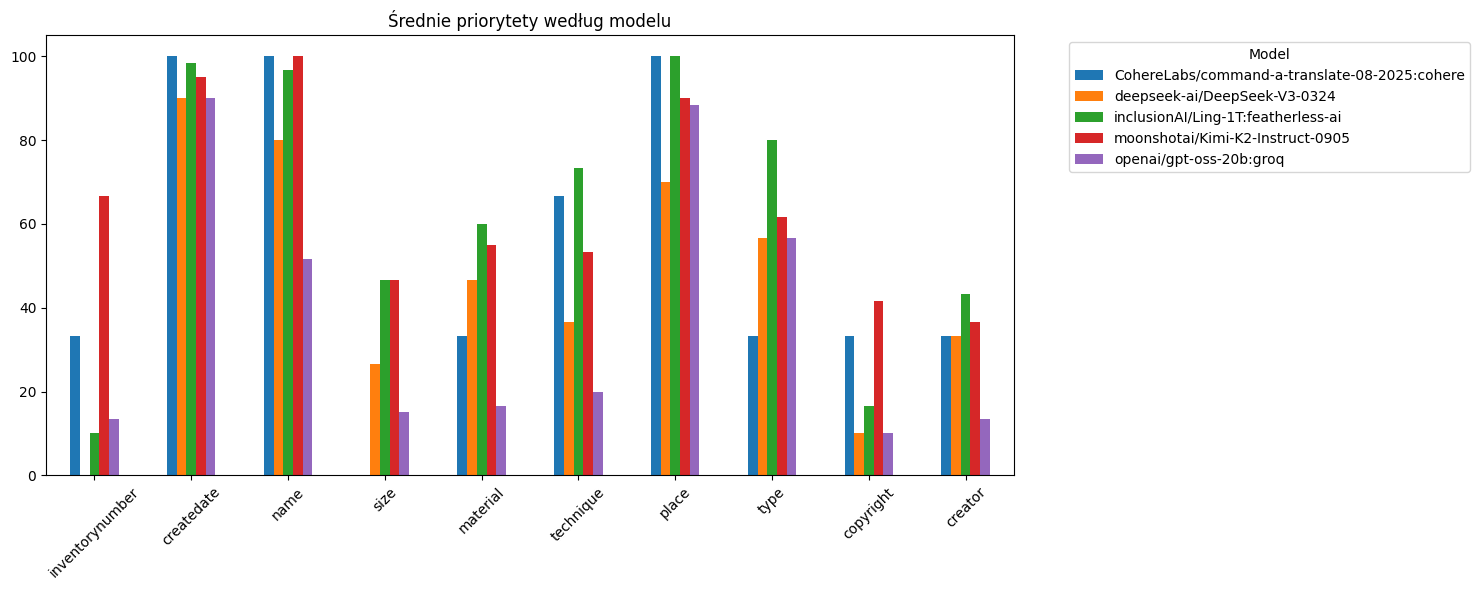

In [61]:
features = ['inventorynumber', 'createdate', 'name', 'size', 'material', 'technique', 'place', 'type', 'copyright', 'creator']
fig, ax = plt.subplots(figsize=(15,6))
model_means = df.groupby('model')[features].mean().T
model_means.plot(kind='bar', ax=ax)
ax.set_title('Średnie priorytety według modelu')
ax.legend(title='Model', bbox_to_anchor=(1.05, 1))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

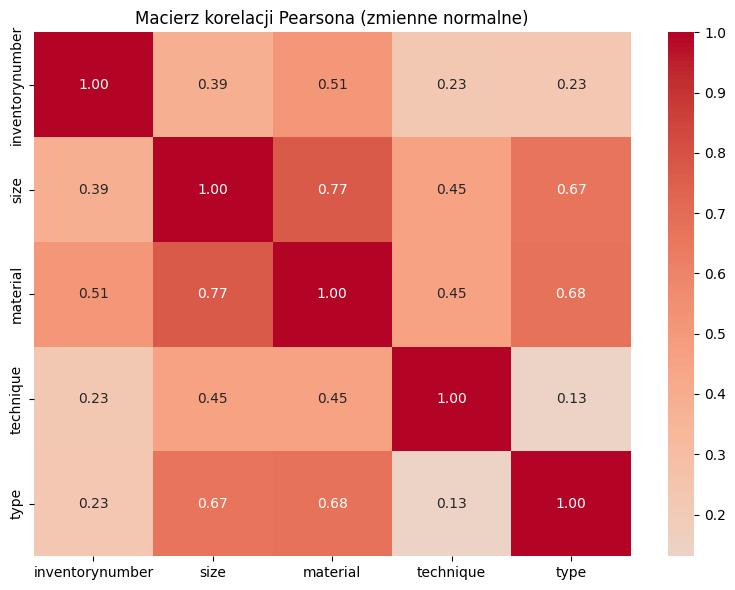

In [62]:
fig, ax = plt.subplots(figsize=(8, 6))
normal_features = ['inventorynumber', 'size', 'material', 'technique', 'type']
corr_matrix = df[normal_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Macierz korelacji Pearsona (zmienne normalne)')
plt.tight_layout()
plt.show()

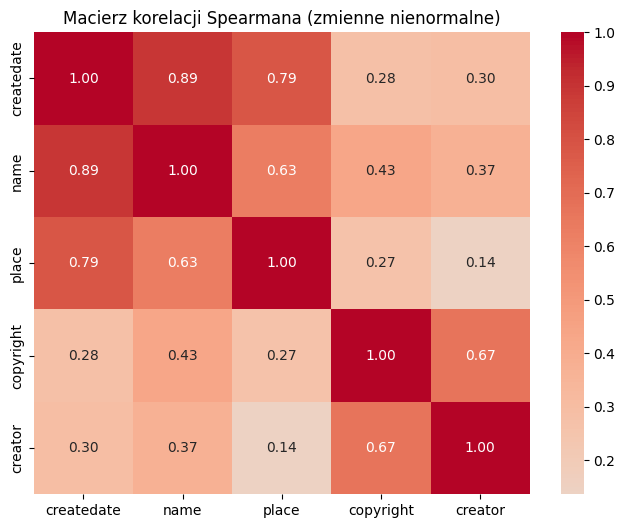

In [63]:
nonnormal_features = ['createdate', 'name', 'place', 'copyright', 'creator']
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
for col in nonnormal_features:
    df_encoded[col] = LabelEncoder().fit_transform(df[col])
corr_matrix_spearman = df_encoded[nonnormal_features].corr(method='spearman')
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix_spearman, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Macierz korelacji Spearmana (zmienne nienormalne)')
plt.show()

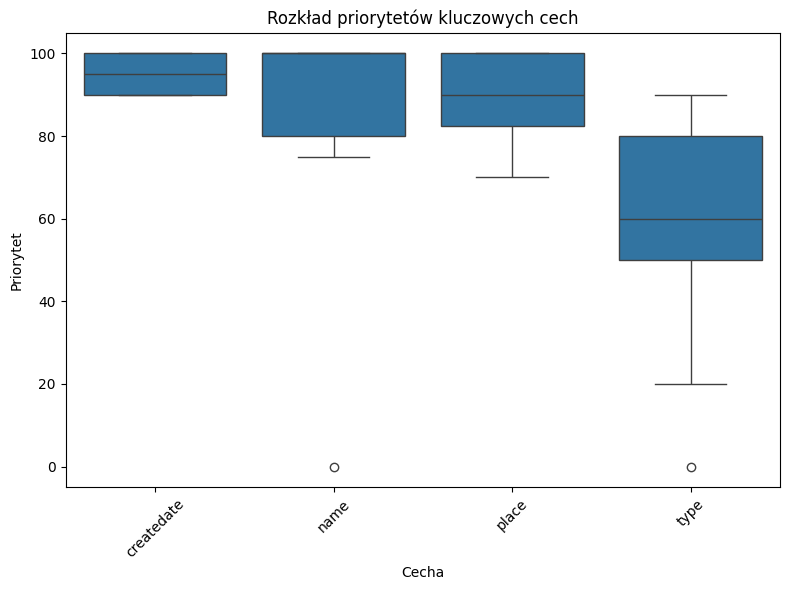

In [64]:
fig, ax = plt.subplots(figsize=(8, 6))
key_features = ['createdate', 'name', 'place', 'type']
df_melted = df.melt(id_vars=['model'], value_vars=key_features, var_name='Cecha', value_name='Priorytet')
sns.boxplot(data=df_melted, x='Cecha', y='Priorytet', ax=ax)
ax.set_title('Rozkład priorytetów kluczowych cech')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

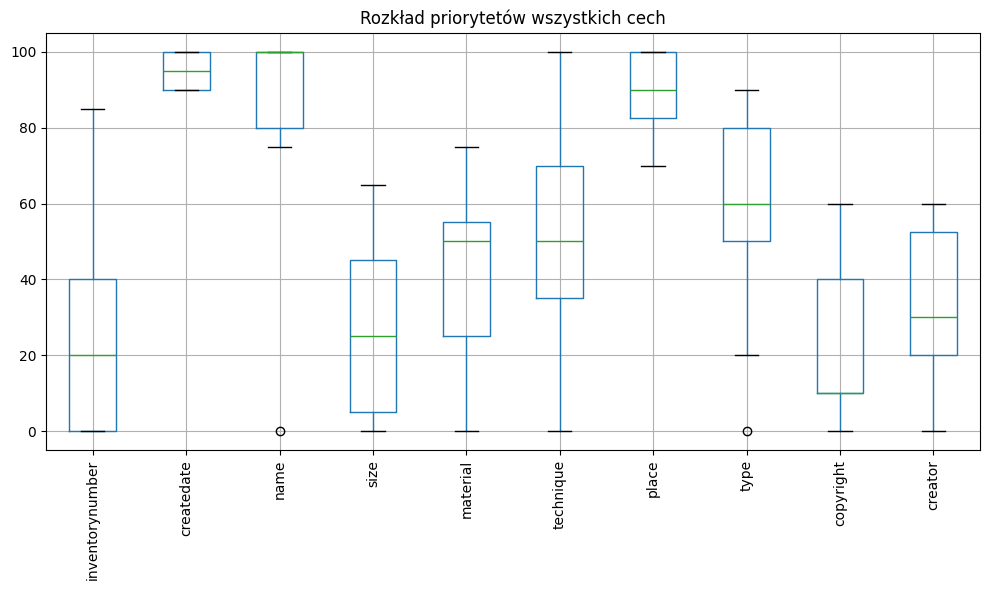

In [65]:
fig, ax = plt.subplots(figsize=(10, 6))
df[features].boxplot(ax=ax)
ax.set_title('Rozkład priorytetów wszystkich cech')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

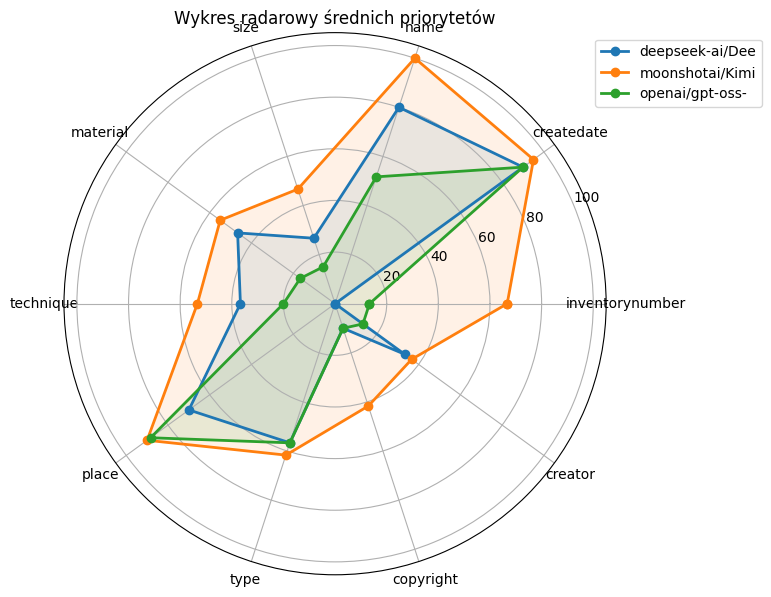

In [66]:
angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for model in df['model'].unique()[:3]:
    model_data = df[df['model'] == model]
    values = model_data[features].mean().tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model[:15])
    ax.fill(angles, values, alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features)
ax.set_title('Wykres radarowy średnich priorytetów')
ax.legend(bbox_to_anchor=(1.3, 1))
plt.tight_layout()
plt.show()